In [9]:
from dotenv import load_dotenv

load_dotenv('.env', override=True)

True

Loading an .env with OPENAI_API_KEY is crucial for this notebook, using the requirements.txt before using the notebook is a must.

In [29]:
from langchain.embeddings import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings()

c:\Users\lanita\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_core\_api\deprecation.py:139: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import OpenAIEmbeddings`.
  warn_deprecated(


In [45]:
texts= [
        "Hi there!",
        "Oh, hello!",
        "What's your name?",
        "My friends call me Lanita",
        "Lanita is the quuen of carmela de fredes con Bombero Sanders!",
        "testing lowest cosine smilarity",
    ] 
embeddings = embeddings_model.embed_documents(texts)
len(embeddings), len(embeddings[0])

(6, 1536)

In [46]:
query = "What was the name mentioned in the conversation?"
embedded_query = embeddings_model.embed_query(query)
embedded_query[:6]

[0.0053772740534241935,
 -0.0006527779663918577,
 0.038980290283414216,
 -0.002967397499514861,
 -0.008834564037682272,
 0.02119239807937076]

In [47]:
import numpy as np
# Calculate Cosine Similarity
# Function to calculate cosine similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Calculate similarities
similarities = [cosine_similarity(embedded_query, emb) for emb in embeddings]
similarities

[0.7691806148023383,
 0.7845615915691082,
 0.834811187108086,
 0.7834607407031237,
 0.7496934200819465,
 0.6744053139385443]

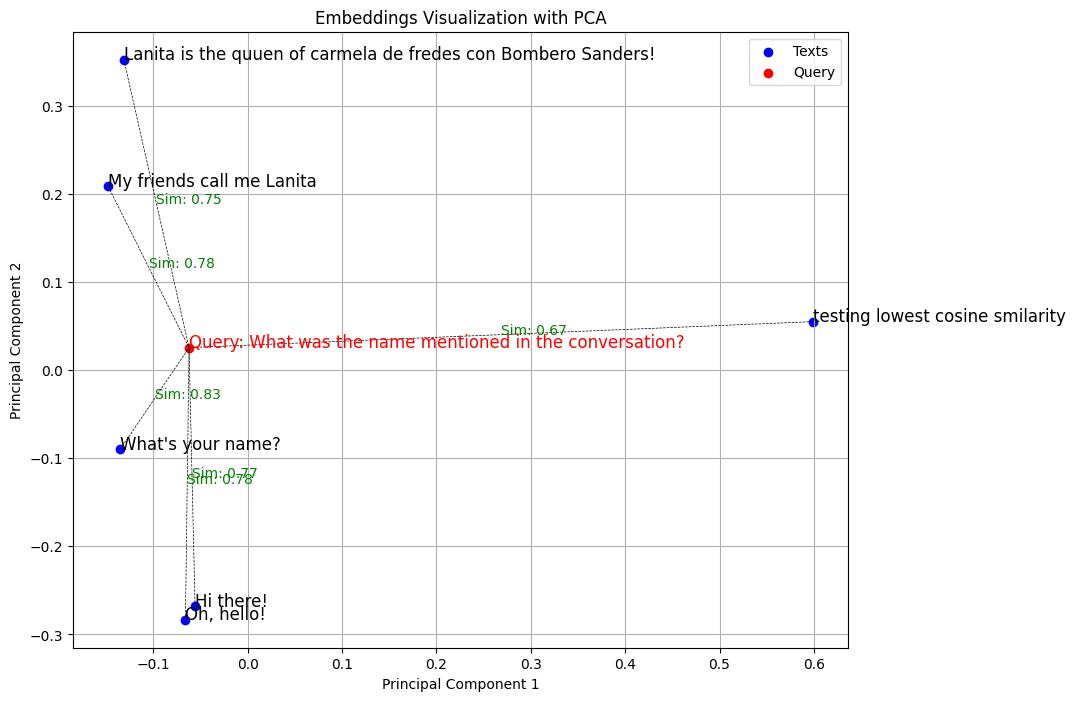

In [41]:
# Plot the Embeddings Using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_embeddings_detailed(embeddings, embedded_query, texts, query):
    # Reduce dimensions with PCA
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(np.vstack((embeddings, embedded_query)))

    plt.figure(figsize=(10, 8))

    # Plot text embeddings
    plt.scatter(reduced_embeddings[:-1, 0], reduced_embeddings[:-1, 1], label='Texts', color='blue')
    for i, text in enumerate(texts):
        plt.annotate(text, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), fontsize=12)
    
    # Plot query embedding
    plt.scatter(reduced_embeddings[-1, 0], reduced_embeddings[-1, 1], label='Query', color='red')
    plt.annotate("Query: " + query, (reduced_embeddings[-1, 0], reduced_embeddings[-1, 1]), fontsize=12, color='red')

    # Draw lines from query to each text
    for i, text in enumerate(texts):
        plt.plot([reduced_embeddings[i, 0], reduced_embeddings[-1, 0]], [reduced_embeddings[i, 1], reduced_embeddings[-1, 1]], 'k--', linewidth=0.5)
        mid_x = (reduced_embeddings[i, 0] + reduced_embeddings[-1, 0]) / 2
        mid_y = (reduced_embeddings[i, 1] + reduced_embeddings[-1, 1]) / 2
        plt.annotate(f"Sim: {similarities[i]:.2f}", (mid_x, mid_y), fontsize=10, color='green')

    plt.title("Embeddings Visualization with PCA")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the function to plot embeddings with detailed annotations
plot_embeddings_detailed(embeddings, embedded_query, texts, query)



Cosine similarity is being displayed here, linking the query with the Plots 

Without RAG we are going to use an prompt that mock the behavior, by passing the texts directly without embeddings we are simulating an RAG behaviour

In [48]:
from langchain.llms import OpenAI
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain

# Initialize the OpenAI model
llm = OpenAI()

# Define the prompt template
prompt_template = PromptTemplate.from_template("""
You are a helpful assistant. Based on the following texts and a query, provide a detailed and helpful answer.

Texts:
{texts}

Query: {query}

Answer:
""")

# Create the prompt
texts_joined = "\n".join(texts)
inputs = {"texts": texts_joined, "query": query}

# Use LangChain to generate an answer
chain = LLMChain(llm=llm, prompt=prompt_template)
response = chain.run(inputs)

# Print the response
print(response)


The name mentioned in the conversation was Lanita.



## Understanding Detailed Embeddings Visualization

### Embeddings and PCA
- **Embeddings**: Each text and query are converted into high-dimensional vectors (embeddings) that capture their semantic meaning.
- **PCA (Principal Component Analysis)**: This technique reduces the high-dimensional embeddings to two dimensions for easier visualization. The axes (Principal Component 1 and 2) are the principal components that capture the most variance in the data.

### Plot Points
- **Blue Points**: Each blue point represents an embedding of a text from your dataset.
- **Red Point**: The red point represents the embedding of your query.

### Annotations
- The blue text labels indicate the original texts corresponding to the embeddings.
- The red text label indicates the query.
- Green annotations on the connecting lines show the cosine similarity values between the query and each text.

### Cosine Similarity
- **Cosine Similarity**: A measure of similarity between two vectors. It ranges from -1 (completely dissimilar) to 1 (completely similar). In this plot, higher values indicate greater similarity.
- Lines connect the query to each text, with similarity values annotated. These values show how closely related the query is to each text.

### How Similarity Affects the Chat Model

#### Contextual Understanding
- The chat model (e.g., GPT-4) uses the context provided by the embeddings to understand which texts are most relevant to the query.
- Higher similarity values indicate that the model considers those texts more relevant to the query.

#### Generating Responses
- When generating a response, the model takes into account the texts with the highest similarity scores.
- These texts are likely given more weight in the model’s internal processing to generate a coherent and contextually appropriate response.

### Practical Implications

#### Query Relevance
- In this case, the query "What was the name mentioned in the conversation?" has a higher similarity with "What's your name?" (similarity 0.83), indicating that the model finds this text semantically relevant to the query.
- However, **for Retrieval-Augmented Generation (RAG)**, it's crucial to prioritize texts that contain the actual answer, even if they have a slightly lower similarity score.
- For example, if another text ("My friend's name is John") has a similarity of 0.73 but contains the answer, it should be prioritized over "What's your name?" because it directly provides the information sought by the query.

#### Model Behavior with RAG
- In RAG, the retrieval mechanism fetches the most relevant documents based on similarity scores.
- The generation mechanism (e.g., GPT-4) then uses these documents to generate an answer.
- **Important Note**: Even if a text like "What's your name?" has a higher similarity score, the retrieval mechanism should prioritize texts that are more likely to contain the actual answer to ensure accurate responses.

### Example Scenario

Let’s consider an example where your texts are about introducing people:

- **Texts**:
  - "Hello world"
  - "How are you?"
  - "Goodbye"
  - "What's your name?"
  - "My friend's name is John."

- **Query**:
  - "What was the name mentioned in the conversation?"

The plot shows that "What's your name?" has the highest similarity to the query, indicating it's semantically relevant. However, "My friend's name is John" contains the actual answer and should be prioritized in a retrieval-augmented setting.

### Conclusion

By visualizing the embeddings and understanding their similarities, you can see how the model prioritizes certain texts over others based on their relevance to the query. This insight helps you understand the model’s behavior and how it uses the provided context to generate accurate and relevant responses. In a Retrieval-Augmented Generation (RAG) system, it's crucial to ensure that texts containing the actual answer are given priority, even if their similarity scores are slightly lower, to ensure the model provides accurate and useful answers.
#

For the next step, we are going to use langchain together with croma vector db.

In [9]:
import bs4
from langchain import hub
from langchain_chroma import Chroma
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.schema import Document
from langchain.llms import OpenAI

In [43]:
from langchain_core.document_loaders import BaseLoader
# Define the custom text loader
class CustomTextLoader(BaseLoader):
    def __init__(self, texts):
        self.texts = texts

    def load(self):
        return [Document(page_content=text) for text in self.texts]


# Load, chunk and index the contents of the textAvs
loader = CustomTextLoader(texts)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=999, chunk_overlap=200)
splits = text_splitter.split_documents(docs)
splits

[Document(page_content='Hi there!'),
 Document(page_content='Oh, hello!'),
 Document(page_content="What's your name?"),
 Document(page_content='My friends call me Lanita'),
 Document(page_content='Lanita is the quuen of carmela de fredes con Bombero Sanders!'),
 Document(page_content='testing lowest cosine smilarity')]

In [49]:
vectorstore = Chroma.from_documents(documents=splits, embedding=OpenAIEmbeddings())
# Retrieve and generate using the relevant snippets of the texts
retriever = vectorstore.as_retriever()
prompt = hub.pull("rlm/rag-prompt")

llm = OpenAI()

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)
query = "is lanita mentioned in the documents? aand what is she called, is she a queen?"
# Invoke the chain with a query
response = rag_chain.invoke(query)
print(response)

 Yes, Lanita is mentioned in the documents as the queen of Carmela de Fredes with Bombero Sanders. She is referred to as "Lanita" and is indeed a queen.


## Conclusion: Linking Cosine Similarity and Retrieval-Augmented Generation (RAG)

### Understanding Cosine Similarity

At the beginning of this notebook, we explored the concept of cosine similarity and its role in determining the semantic similarity between vectors. We used embeddings to represent both the texts and the query in a high-dimensional space, and cosine similarity helped us measure how closely related these vectors are.

### Practical Implications of Cosine Similarity

Cosine similarity is a crucial metric in information retrieval. By calculating the cosine similarity between the query and each text, we can identify which texts are most relevant to the query. This relevance scoring is essential for the retrieval step in RAG, as it ensures that the most contextually appropriate texts are selected to inform the generation process.

### Retrieval-Augmented Generation (RAG)

Retrieval-Augmented Generation (RAG) is a powerful approach that enhances the capabilities of language models like GPT-4 by combining retrieval mechanisms with generation capabilities. Here’s a summary of how RAG works and its advantages:

1. **Retrieval Step**:
   - **Document Retrieval**: In the retrieval step, we use cosine similarity to rank and select the most relevant documents or text snippets from a corpus based on their similarity to the query.
   - **Custom Retriever**: We implemented a custom retriever that loaded predefined texts, chunked them, and indexed them using embeddings. This retriever utilized cosine similarity to fetch the most relevant texts.

2. **Generation Step**:
   - **Contextual Generation**: The retrieved texts are then provided as context to a language model (GPT-4 in this case), which generates a coherent and contextually appropriate response.
   - **Prompt Design**: A carefully designed prompt ensures that the language model uses the provided context effectively to answer the query.

### Example: Task Decomposition Query

In our example, we demonstrated the entire RAG pipeline with a query about "Lanita". By combining cosine similarity for retrieval and GPT-4 for generation, we generated a response that was informed by the most relevant snippets of text.

### Benefits of RAG

- **Enhanced Accuracy**: By retrieving and providing relevant context, RAG significantly improves the accuracy of the generated responses.
- **Contextual Relevance**: RAG ensures that the generated answers are not only accurate but also contextually relevant, as they are based on actual retrieved documents.

### Final Thoughts

This notebook has provided a comprehensive overview of how cosine similarity and Retrieval-Augmented Generation (RAG) work together to enhance the capabilities of language models. By understanding these concepts and their practical applications, you can leverage them to build more powerful and accurate information retrieval and generation systems.

### Summary of Key Points

- **Cosine Similarity**: Measures the semantic similarity between vectors and is used to rank relevance.
- **Embeddings**: Represent texts and queries in a high-dimensional space.
- **RAG Pipeline**: Combines retrieval (using cosine similarity) and generation (using GPT-4) to produce accurate and contextually relevant responses.
- **Practical Implementation**: Demonstrated with predefined texts and a custom retriever.

By mastering these techniques, you can significantly enhance the performance of your language models and build sophisticated retrieval-augmented applications.
